# 09. 데이터 분석 프로젝트 - 한국복지패널 데이터

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
raw_welfare = pd.read_spss('Koweps_hpwc14_2019_beta2.sav')
welfare = raw_welfare.copy()

welfare.shape       # 14418행, 830열

# 1. 일단 변수명을 바꾼다
welfare = welfare.rename(columns={'h14_g3'  :   'sex',
                                  'h14_g4'  :   'birth',
                                  'h14_g10' :   'marriage_type',
                                  'h14_g11' :   'religion',
                                  'p1402_8aq1'  :   'income',
                                  'h14_eco9'    :   'code_job',
                                  'h14_reg7'    :   'code_region'})

## 1. 변수 검토 , 전처리
1. 변수의 특징 파악 ( df.shape , df.info(), df.describe())
2. 이상치, 결측치 처리 (df.isna().sum(), df.dropna(subset=[..]))
3. 변수를 필요에 맞게 가공
## 2. 변수간 관계분석
1. 데이터를 요약한 표와 그래프 출력력


# 성별과 월급간의 상관관계를 분석해보자

<class 'pandas.core.series.Series'>
RangeIndex: 14418 entries, 0 to 14417
Series name: sex
Non-Null Count  Dtype  
--------------  -----  
14418 non-null  float64
dtypes: float64(1)
memory usage: 112.8 KB


<Axes: xlabel='sex', ylabel='count'>

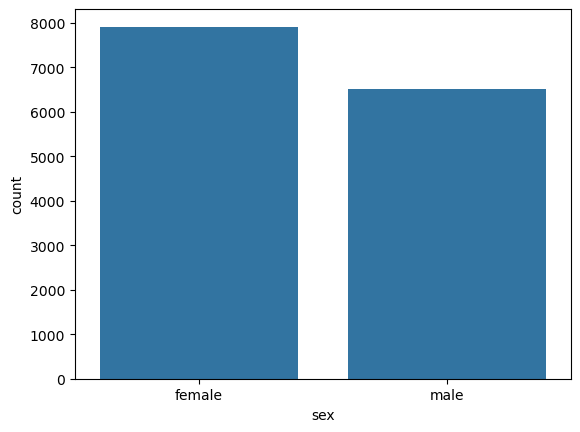

In [5]:

# 1. 'sex'변수부터 


#1. 변수의 특징파악
welfare['sex'].dtypes
welfare['sex'].info()

#2. 이상치 , 결측치 확인
welfare['sex'].isna().sum()

#3. 변수를 필요에 맞게 가공
welfare['sex'] = np.where(welfare['sex'] == 1, 'male','female')

sns.countplot(data=welfare, x='sex')


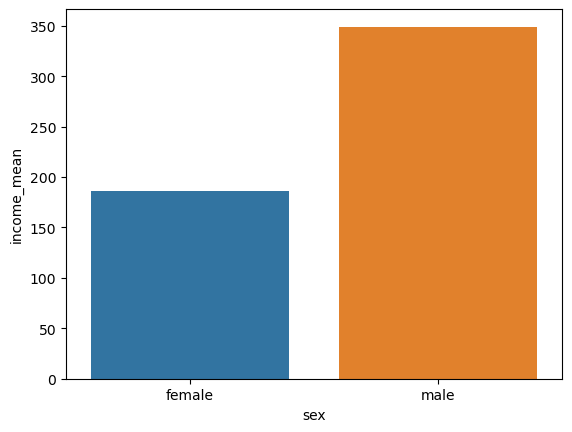

In [6]:
# 2. 'income'변수 분석
# 1. 구조분석 2. 결측치,이상치 제거 3. 변수이름 변경
#welfare['income'].info()
#welfare['income'].describe()

#2.
#welfare['income'].isna().sum()
#sns.boxenplot(data=welfare, y='income')

# pct25 = welfare['income'].quantile(.25)
# pct50 = welfare['income'].quantile(.50)
# pct75 = welfare['income'].quantile(.75)
# iqr = pct75 - pct25
# low = pct25 - (iqr * 1.5)
# high = pct75 + (iqr * 1.5)
# print(f'최소값 : {low} , 최대값 : {high}')

sex_income = welfare.dropna(subset=['income']).groupby('sex').agg(income_mean = ('income','mean'))
sns.barplot(data = sex_income, x='sex', y='income_mean',hue='sex');

## 나이와 월급의 관계

<Axes: xlabel='age', ylabel='mean_income'>

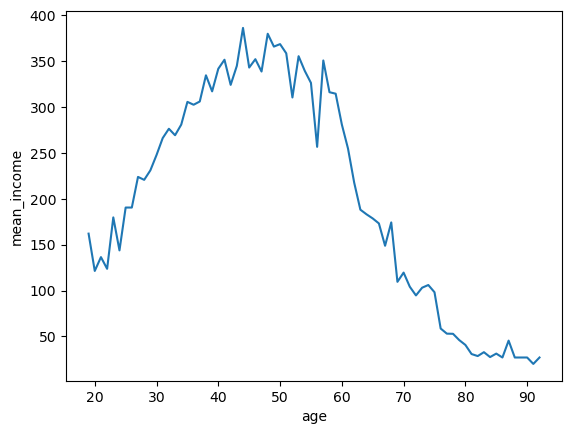

In [7]:

welfare['birth'].dtypes # float64타입
welfare['birth'].describe() #이상값 없다 (모름:9999 하지만 최대값이 2018)
welfare['birth'].isna().sum() #0 . 결측치 없다

# 출생연도가 필요없으므로 필요한 나이로 바꾼다
welfare = welfare.assign(age = 2019 - welfare['birth'] + 1) # 만나이 +1 계산

age_income = welfare.dropna(subset=['birth']).groupby('age').agg(mean_income = ('income','mean'))
sns.lineplot(data=age_income, x='age',y='mean_income')


## 연령대에 따른 월급차이

<Axes: xlabel='gen', ylabel='mean_income'>

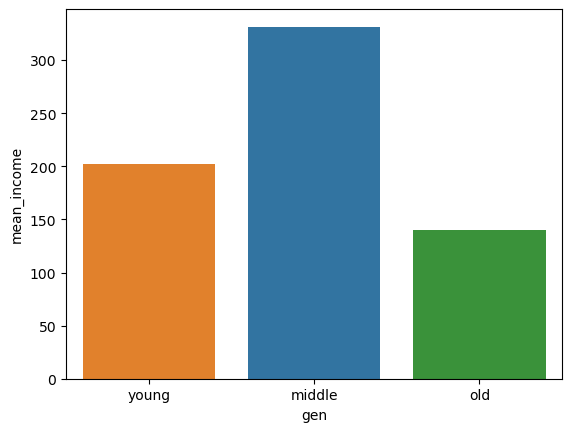

In [8]:
welfare['gen'] = np.where(welfare['age'] >= 60, 'old',np.where(welfare['age'] > 30 , 'middle','young'))
gen_income = welfare.groupby('gen').agg(mean_income = ('income','mean')).sort_values('mean_income',ascending=False)

sns.barplot(data = gen_income, x='gen',y='mean_income',order=['young','middle','old'],hue='gen')

## 연령대 및 성별 월급 차이


<Axes: xlabel='gen', ylabel='mean_income'>

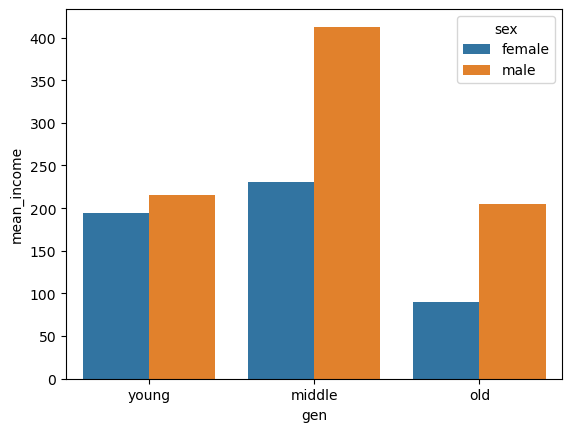

In [9]:
gen_sex_income = welfare.dropna(subset=['income']).groupby(['gen','sex']).agg(mean_income = ('income','mean'))
sns.barplot(data=gen_sex_income, x='gen',y='mean_income',hue='sex',order=['young','middle','old'])

## 나이 및 성별 월급 차이


<Axes: xlabel='age', ylabel='mean_income'>

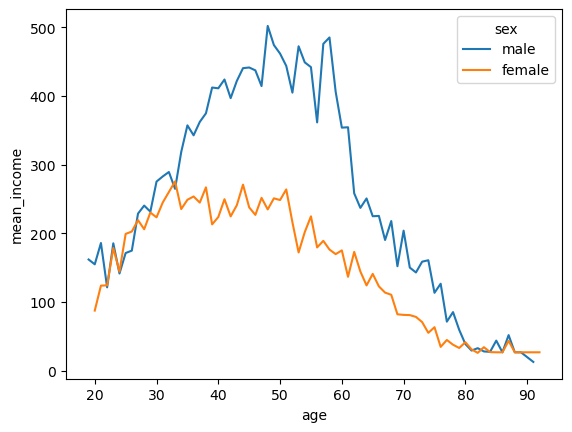

In [10]:
age_sex_income = welfare.dropna(subset=['income']).groupby(['age','sex']).agg(mean_income = ('income','mean'))
sns.lineplot(data=age_sex_income, x='age',y='mean_income',hue='sex')


## 직업별 월급차이


In [11]:
list_job = pd.read_excel('Koweps_Codebook_2019.xlsx',sheet_name='직종코드')
list_job.head()
welfare = pd.merge(welfare,list_job, how = 'left',on='code_job')    

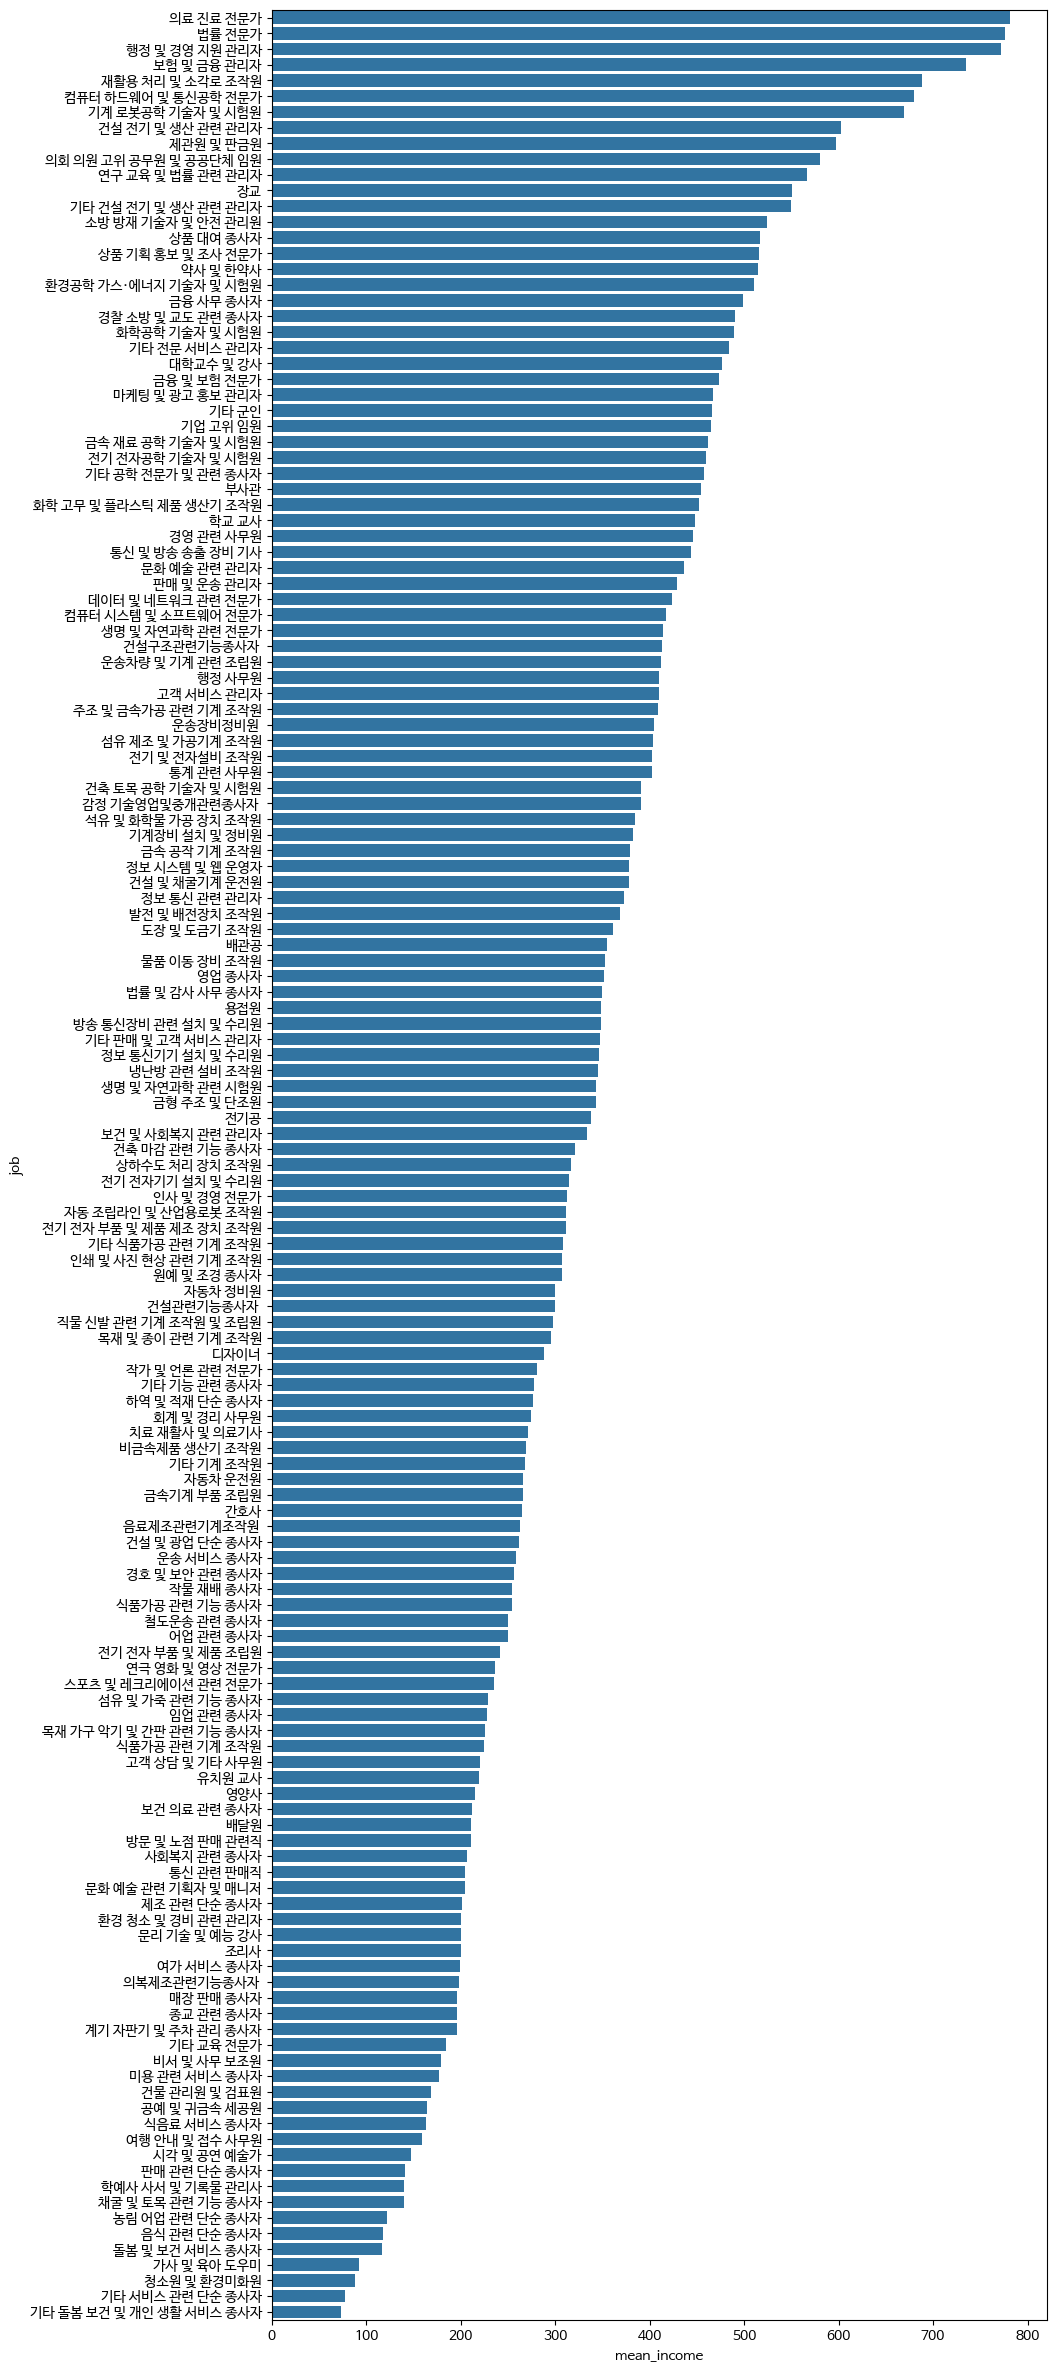

In [27]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams['font.family'] = 'NanumBarunGothic' 

# 한글출력
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']
# plt.rcParams['axes.unicode_minus'] = False

# 직업별 월급평균표를 만들어보자
job_income = welfare.dropna(subset=['job','income']).groupby('job',as_index=False).agg(mean_income = ('income','mean')).sort_values('mean_income',ascending=False)

plt.figure(figsize=(10, 30))
sns.barplot(data=job_income, y='job', x='mean_income');

# 월급 상위 10위

<Axes: xlabel='mean_income', ylabel='job'>

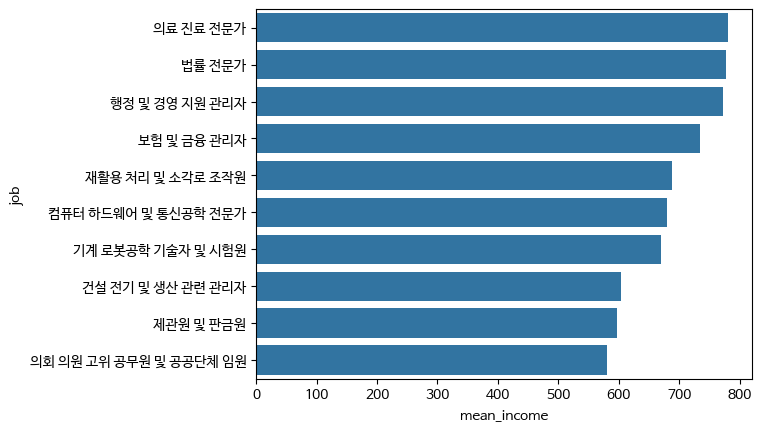

In [28]:
# 월급 상위 10위
top_10 = job_income.sort_values('mean_income',ascending=False).head(10)
sns.barplot(data=top_10, y='job', x='mean_income')

# 월급 하위 10위

<Axes: xlabel='mean_income', ylabel='job'>

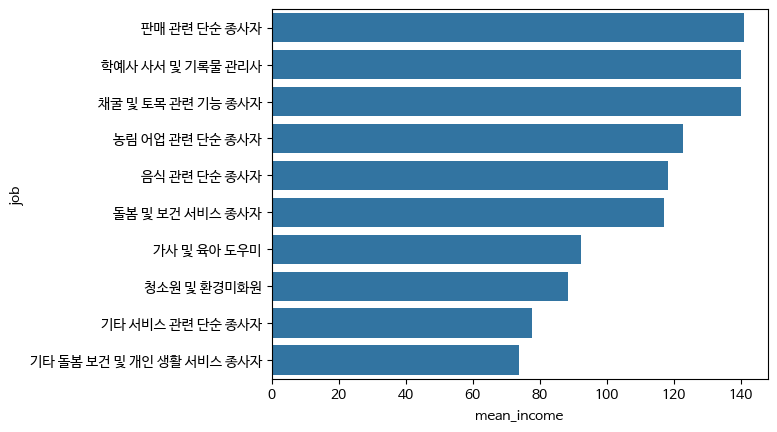

In [29]:
# 월급 하위 10위
bottom_10 = job_income.sort_values('mean_income',ascending=False).tail(10)
sns.barplot(data=bottom_10, y='job', x='mean_income')

## 성별에 따른 직업빈도

<Axes: xlabel='n', ylabel='job'>

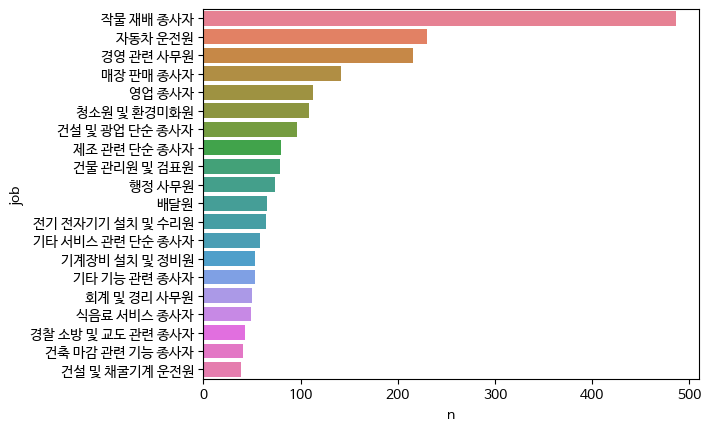

In [32]:
plt.rcParams['axes.unicode_minus'] = False

# 남자
job_male = welfare.dropna(subset=['job']).query('sex == "male"').groupby('job',as_index=False).agg(n=('job','count')).sort_values('n',ascending=False).head(20)
sns.barplot(data=job_male, x='n', y='job',hue='job')

# 여자
# job_female = welfare.dropna(subset=['job']).query('sex == "female"').groupby('job',as_index=False).agg(n=('job','count')).sort_values('n',ascending=False).head(20)
# sns.barplot(data=job_female, x='n', y='job',hue='job')